<div align="center">

# Replicating the Commission Reference Trajectories

Lennard Welslau\
lennard.welslau[at]gmail[dot]com\
September 2026

</div>

In [1]:
# Import libraries and modules
import numpy as np
import pandas as pd
pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns, pd.options.display.max_rows = 100, 100
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# Import classes and data pipeline
from classes import StochasticDsaModel as DSA
from data_pipeline import read_country, EU27, REPO_ROOT
from data_pipeline.commission import load_prior_guidance

# Set autoreload
%load_ext autoreload
%autoreload 2

# TOC
1. **Background**: the Commission prior guidance calculation sheets
2. **Input data**: building a workbook from the Commission sheets
3. **Debt dynamics**: replicating the Commission adjustment scenario
4. **Rules**: the default rules of the model and the rules of the Commission prior guidance
5. **Example**: France
6. **All countries**: replication with the Commission rules and comparison with the default rules
7. **Decomposition and discussion**: what drives the deviations, and which reading of the regulation

## Background

- Before member states submitted their medium-term fiscal-structural plans, the Commission transmitted *prior guidance*: a **reference trajectory** for countries with debt above 60% or a deficit above 3% of GDP, and **technical information** for the others.
- For each country, the Commission published a **calculation sheet** (Excel) on its fiscal surveillance pages. The sheets contain the Commission's inputs (forecast, market expectations from Bloomberg, debt structure, ageing costs, stock-flow adjustments) and a simplified Excel version of its Stata model.
- The `data_pipeline` downloads these sheets and maps them to the model inputs. Running the model on these inputs allows a direct comparison with the Commission results.
- The 2024 guidance is based on the Commission 2024 spring forecast for most countries (autumn 2024 for AT, BE, BG, LT; spring 2025 for DE). Later guidance was issued for HU (updated), IE and NL (autumn 2025) and CZ (spring 2026).

## Input data

- `build_inputs(mode='commission')` downloads the calculation sheets (saved in `data/RawData/commission_prior_guidance`) and builds an input workbook with **all inputs taken from the Commission sheets**.
- The resulting workbooks `dsa_inputs_commission_2024.xlsx` and `dsa_inputs_commission_latest.xlsx` are included in `data/InputData`. Each country sheet documents the source of every value; user assumptions can be added in the *Overrides* sheet.
- The workbook also carries the settings needed for replication, e.g. the EDP status in T, the last forecast year, and the multiplier specification (Commission output gap rule, multiplier of 0.75 in 2024 guidance and 0.6 in guidance issued from 2025).

In [2]:
# Rebuild the workbook from the Commission sheets (downloads missing sheets and historical shock data)
# from data_pipeline.build import build_inputs
# build_inputs(mode='commission', prior_guidance='2024')

series, params = read_country('dsa_inputs_commission_2024.xlsx', 'FRA')
pd.Series(params).to_frame('FRA')

,FRA
REFERENCE_YEAR,"2,024.00"
LAST_FORECAST_YEAR,"2,025.00"
EXCESSIVE_DEFICIT_PROCEDURE,1.00
FISCAL_MULTIPLIER,0.75
FISCAL_MULTIPLIER_PERSISTENT,0.00
BUDGET_BALANCE_ELASTICITY,0.63
DEBT_ST_SHARE,0.10
DEBT_LT_MATURING_SHARE,0.08
DEBT_LT_MATURING_AVG_SHARE,0.08
DEBT_DOMESTIC_SHARE,1.00


In [3]:
series.loc[2023:2034, ['DEBT_RATIO', 'STRUCTURAL_PRIMARY_BALANCE', 'REAL_GDP_GROWTH', 'POTENTIAL_GDP_GROWTH',
                        'GDP_DEFLATOR_PCH', 'INTEREST_RATE_LT', 'INTEREST_RATE_ST', 'STOCK_FLOW_RATIO', 'AGEING_COST']]

,DEBT_RATIO,STRUCTURAL_PRIMARY_BALANCE,REAL_GDP_GROWTH,POTENTIAL_GDP_GROWTH,GDP_DEFLATOR_PCH,INTEREST_RATE_LT,INTEREST_RATE_ST,STOCK_FLOW_RATIO,AGEING_COST
YEAR,,,,,,,,,
2023,110.64,-3.65,0.70,1.14,5.47,2.99,3.43,-0.22,NaN
2024,112.41,-2.97,0.73,1.09,2.77,2.96,3.56,0.21,27.64
2025,113.64,-2.97,1.59,1.00,2.04,3.06,2.82,0.03,27.58
2026,116.03,-2.97,0.58,0.63,2.11,3.14,2.81,0.00,27.59
2027,NaN,NaN,0.38,0.44,2.17,3.21,2.79,0.00,27.65
2028,NaN,NaN,0.31,0.34,2.23,3.29,2.78,0.00,27.66
2029,NaN,NaN,0.34,0.34,2.30,3.36,2.77,0.00,27.64
2030,NaN,NaN,0.35,0.35,2.36,3.44,2.76,0.00,27.62
2031,NaN,NaN,0.37,0.37,2.42,3.51,2.75,0.00,27.61


## Debt dynamics

- First, we feed the model the Commission's SPB path from the *Adjustment scenario* sheet and compare the resulting debt path.
- This tests the debt dynamics (growth and multiplier effects, implicit interest rate, ageing costs, stock-flow) independently of the optimisation.

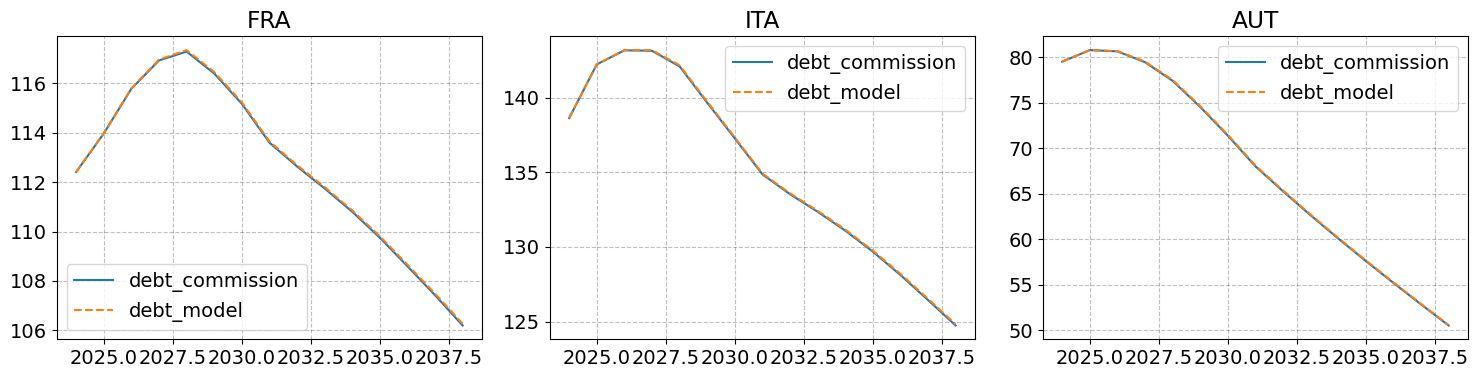

In [4]:
sheets = load_prior_guidance(EU27, vintage='2024')

def replicate_adjustment_scenario(country, input_file='dsa_inputs_commission_2024.xlsx'):
    sheet = sheets[country]
    T = sheet.T
    spb_path = sheet.row('Adjustment scenario', r'^Structural primary balance').loc[T:sheet.adjustment_end].to_numpy()
    model = DSA(country, input_file=input_file, adjustment_period=sheet.adjustment_end - T)
    model.project(spb_steps=np.diff(spb_path))
    return pd.DataFrame({
        'debt_commission': sheet.row('Adjustment scenario', r'^Gross debt'),
        'debt_model': model.df('d')['d'].droplevel('t'),
        'balance_commission': sheet.row('Adjustment scenario', r'^Headline balance'),
        'balance_model': model.df('ob')['ob'].droplevel('t'),
    }).loc[T:T + 14]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, country in zip(axes, ['FRA', 'ITA', 'AUT']):
    df = replicate_adjustment_scenario(country)
    df[['debt_commission', 'debt_model']].plot(ax=ax, style=['-', '--'], title=country)
plt.tight_layout()

In [5]:
# Maximum absolute difference in debt and headline balance to T+14 (pp. of GDP) for all countries
pd.DataFrame({
    c: {'debt': (d['debt_model'] - d['debt_commission']).abs().max(),
        'balance': (d['balance_model'] - d['balance_commission']).abs().loc[sheets[c].T + 1:].max()}
    for c in EU27 for d in [replicate_adjustment_scenario(c)]
}).T.round(3).T

,AUT,BEL,BGR,HRV,CYP,CZE,DNK,EST,FIN,FRA,DEU,GRC,HUN,IRL,ITA,LVA,LTU,LUX,MLT,NLD,POL,PRT,ROU,SVK,SVN,ESP,SWE
debt,0.10,0.10,0.01,0.03,0.03,0.00,9.94,0.00,0.06,0.07,0.04,0.02,0.06,0.11,0.08,0.01,0.01,0.00,0.07,0.00,0.07,0.23,0.10,0.09,0.02,0.08,0.02
balance,0.03,0.03,0.00,0.01,0.00,0.00,0.22,0.00,0.02,0.02,0.01,0.00,0.02,0.02,0.02,0.00,0.00,0.00,0.02,0.00,0.02,0.04,0.03,0.03,0.01,0.02,0.00


- Debt paths match within about 0.1 pp. of GDP over 14 years for almost all countries.
- **Denmark** is the exception: the Commission projects a negative debt ratio from 2034, while the model floors debt at zero.

## Rules

The required adjustment follows from the rules of Regulation (EU) 2024/1263: the DSA criteria (debt declining or staying at prudent levels after the adjustment period, deficit below 3%), the EDP, and the debt sustainability and deficit resilience safeguards. `find_spb_binding` implements these rules in two versions:

- **Default rules** (Darvas, Welslau and Zettelmeyer, 2024), the model default: a consistent translation of the legal text. The DSA-based SPB target is reached linearly; the minimum steps of the EDP and the deficit resilience safeguard front-load the adjustment where they bind, and later steps are reduced so that the target is unchanged; the debt safeguard applies from the year the EDP is projected to be abrogated.
- **Commission rules** (`rules='commission'`): the implementation of the Commission prior guidance calculation sheets, used for the reference trajectories. The DSA-based adjustment is the smallest constant annual step such that debt declines over 10 years after the adjustment period in all deterministic scenarios and with 70% probability in the stochastic projection, or debt is below 60% in all scenarios, with the deficit below 3%. Minimum steps of the EDP and the deficit resilience safeguard are added on top; the debt safeguard is then met with the smallest constant step above the DSA-based one. Countries with debt below 60% and a deficit below 3% receive technical information (deficit criterion and debt below 60% only).

Each rule can also be switched individually (e.g. `find_spb_binding(frontloading=False)`):

| Rule | Default: Darvas, Welslau and Zettelmeyer (2024) | Commission prior guidance sheets (`rules='commission'`) | Option |
|---|---|---|---|
| Adjustment path | Sequential: the DSA-based target is reached linearly; EDP and deficit resilience steps **front-load** the adjustment and later steps are reduced to keep the target | **Constant** annual adjustment; EDP and deficit resilience minimum steps are added on top where they bind | `frontloading` |
| DSA criteria | Per deterministic scenario: debt declines *or* is below 60%; deficit below 3% | Debt declines in *all* scenarios and stochastically, *or* debt below 60% in all scenarios; deficit below 3%. Countries with debt < 60% and deficit < 3% get *technical information* (deficit and debt below 60% only) | `dsa_criteria` |
| Stochastic criterion | Debt declines, or is below 60%, with 70% probability | Debt declines with 70% probability | `stochastic_criteria` |
| EDP status in T | From the input data, as in the Commission prior guidance; `edp_status='infer'` lets the model predict it from a projected deficit above 3%, `True`/`False` set it | From the input data | `edp_status` |
| EDP | Minimum steps of 0.5 pp. while the deficit exceeds 3%, front-loaded | Min. 0.5 pp. step after a year with a deficit above 3%, added on top; abrogated after two years with a deficit below 3% | `edp` |
| Debt safeguard | Average decline from the year the EDP is projected to be abrogated (the year after the deficit falls below 3%, if it stays below 3%, as in the Commission sheets), or T without EDP, to the end of adjustment: 1 pp. if debt in T > 90%, 0.5 pp. otherwise | Debt band by start-of-year debt (> 90%, 60-90%), averaged over adjustment years outside the EDP | `debt_safeguard` |
| Deficit resilience | Steps raised (up to 0.4/0.25 pp.) until the structural deficit is below 1.5% in the same year | 0.4/0.25 pp. step after a year with a structural deficit above 1.55% | `deficit_resilience` |
| Precision | Exact SPB target | Annual adjustment rounded up to 0.01 pp.; floor of 0 pp. (reference trajectory) or -1 pp. (technical information) | `grid` |

In both versions, the EDP benchmark applies to the SPB until 2027 and to the structural balance from 2028 (Regulation (EU) 2024/1264, recital 23; `EDP_SPB_TERMS_LAST_YEAR`).

Below, we reproduce the Commission reference trajectories with the Commission rules and compare them with the results of the default rules, using the same inputs from the Commission sheets.

## Example: France

France (2024 guidance, reference trajectory, in EDP) with both rules, for 4- and 7-year adjustment periods.

In [6]:
results = {}
for rules in ['commission', 'default']:
    for n in [4, 7]:
        model = DSA('FRA', input_file='dsa_inputs_commission_2024.xlsx', adjustment_period=n)
        np.random.seed(0)
        model.find_spb_binding(rules=rules, print_results=(rules == 'commission' and n == 4))
        results[(rules, n)] = model

commission = sheets['FRA'].results()
pd.DataFrame({
    f'{n}-year': {
        'Commission: DSA-based annual adjustment': commission[f'annual_adjustment_dsa_{n}y'],
        'Commission rules: DSA-based annual adjustment': results[('commission', n)].binding_parameter_dict['annual_adjustment_dsa'],
        'Commission: SPB at end of adjustment': commission[f'spb_end_{n}y'],
        'Commission rules: SPB at end of adjustment': results[('commission', n)].spb_target_dict['binding'],
        'Default rules: SPB at end of adjustment': results[('default', n)].spb_target_dict['binding'],
    } for n in [4, 7]})

**Summary**

,FRA
Country,France
Adjustment period,2025-2028
Rules,commission
Guidance,reference trajectory
Binding criterion,Deficit below 3% (DSA)
SPB in T (% of GDP),-2.97
DSA-based SPB target (% of GDP),0.91
SPB at end of adjustment (% of GDP),0.91
Average annual adjustment (pp.),0.97
Average net expenditure growth (%),0.98


**SPB targets**

,SPB at end of adjustment,Average annual adjustment
Criterion,,
Deficit below 3% (DSA),0.87,0.96
Adjustment scenario: debt declines (DSA),-0.07,0.72
Adjustment scenario: debt below 60% (DSA),4.83,1.95
Lower SPB scenario: debt declines (DSA),0.37,0.83
Lower SPB scenario: debt below 60% (DSA),5.33,2.07
Financial stress scenario: debt declines (DSA),0.49,0.87
Financial stress scenario: debt below 60% (DSA),4.96,1.98
Adverse r-g scenario: debt declines (DSA),0.76,0.93
Adverse r-g scenario: debt below 60% (DSA),5.34,2.08


**Adjustment path**

,Annual SPB adjustment (pp.),EDP minimum step (pp.),Deficit resilience minimum step (pp.),SPB before change in ageing costs (% of GDP),Structural primary balance (% of GDP),Overall balance (% of GDP),Structural balance (% of GDP),Debt (% of GDP),Net expenditure growth (%)
Year,,,,,,,,,
2024,,,,-2.97,-2.97,-5.31,-5.00,112.41,
2025,0.97,0.50,0.40,-2.00,-2.00,-4.73,-4.35,113.98,1.28
2026,0.97,0.50,0.40,-1.03,-1.03,-4.25,-3.55,115.78,0.97
2027,0.97,0.50,0.40,-0.06,-0.06,-3.66,-2.74,116.90,0.85
2028,0.97,0.63,0.40,0.91,0.91,-2.97,-1.90,117.20,0.82
2029,0.00,,,0.91,0.94,-2.67,-1.95,116.20,2.64
2030,0.00,,,0.91,0.95,-2.37,-2.01,114.84,2.71
2031,0.00,,,0.91,0.97,-2.05,-2.05,113.12,2.80
2032,0.00,,,0.91,0.97,-2.10,-2.10,112.04,2.89


,4-year,7-year
Commission: DSA-based annual adjustment,0.94,0.56
Commission rules: DSA-based annual adjustment,0.97,0.56
Commission: SPB at end of adjustment,0.79,1.23
Commission rules: SPB at end of adjustment,0.91,1.22
Default rules: SPB at end of adjustment,0.87,0.84


With a 7-year adjustment period, the EDP minimum steps bind in the first years. The Commission rules add them on top of a constant annual adjustment, which raises the SPB at the end of the adjustment period; the default rules front-load them and reduce later steps. The chart compares the SPB paths with the Commission's reference trajectory.

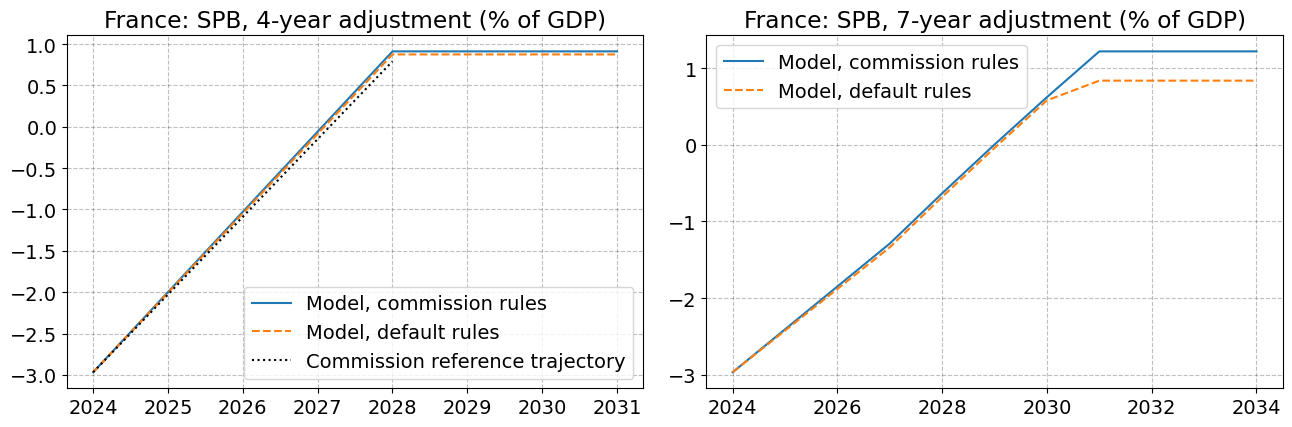

In [7]:
sheet = sheets['FRA']
n_sheet = sheet.adjustment_end - sheet.T   # adjustment period of the Commission's adjustment scenario in the sheet
spb_commission = sheet.row('Adjustment scenario', r'^Structural primary balance').loc[sheet.T:sheet.adjustment_end]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, n in zip(axes, [4, 7]):
    for rules, ls in [('commission', '-'), ('default', '--')]:
        m = results[(rules, n)]
        years = np.arange(m.start_year, m.adjustment_end_year + 4)
        ax.plot(years, m.spb_bca[:len(years)], ls=ls, label=f'Model, {rules} rules')
    if n == n_sheet:
        ax.plot(spb_commission.index, spb_commission.values, ls=':', color='black', label='Commission reference trajectory')
    ax.set_title(f'France: SPB, {n}-year adjustment (% of GDP)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend()
plt.tight_layout()

## All countries

`data_pipeline.validate.compare_with_commission(input_file, rules=...)` runs the model for all countries with the Commission inputs (`dsa_inputs_commission_2024.xlsx`) and compares the SPB at the end of the adjustment period with the Commission's prior guidance. It takes about 10 minutes with stochastic simulations; results are saved in `output/validation`.

- **Commission replication** (`rules='commission'`): the rules as implemented in the Commission prior guidance sheets.
- **Default replication** (`rules='default'`): the default rules of the model, which translate the legal text of the regulation (see section 6).

Both use the same inputs and model settings (e.g. the fiscal multiplier and output gap closure rule of the sheets, EDP status from the input data), so differences arise from the rules only.

In [8]:
# from data_pipeline.validate import compare_with_commission
# summary, _ = compare_with_commission('dsa_inputs_commission_2024.xlsx', rules='commission',
#                                      out_file=REPO_ROOT / 'output' / 'validation' / 'commission_2024_comparison.xlsx')
# summary_default, _ = compare_with_commission('dsa_inputs_commission_2024.xlsx', rules='default',
#                                              out_file=REPO_ROOT / 'output' / 'validation' / 'commission_2024_comparison_default_rules.xlsx')

summary = pd.read_excel(REPO_ROOT / 'output' / 'validation' / 'commission_2024_comparison.xlsx', sheet_name='spb_targets')
summary_default = pd.read_excel(REPO_ROOT / 'output' / 'validation' / 'commission_2024_comparison_default_rules.xlsx', sheet_name='spb_targets')

# SPB at the end of the adjustment period: Commission guidance and the two replications
comparison = summary[['country', 'guidance', 'adjustment_period', 'commission_spb_end']].copy()
comparison['model: Commission rules'] = summary['model_spb_end']
comparison['model: default rules'] = summary_default['model_spb_end']
comparison['default minus Commission rules'] = comparison['model: default rules'] - comparison['model: Commission rules']
comparison['binding criterion (default rules)'] = summary_default['model_binding_criterion']
comparison.rename(columns={'commission_spb_end': 'Commission guidance'}).set_index(['country', 'adjustment_period'])

guidance  Commission guidance  \
country adjustment_period                                               
AUT     4                   reference trajectory                 2.58   
        7                   reference trajectory                 1.88   
BEL     4                   reference trajectory                 1.25   
        7                   reference trajectory                 1.59   
BGR     4                  technical information                -0.87   
        7                  technical information                -0.53   
HRV     4                  technical information                -0.36   
        7                  technical information                -0.21   
CYP     4                   reference trajectory                 3.48   
        7                   reference trajectory                 3.48   
CZE     4                  technical information                 0.39   
        7                  technical information                 0.75   
DNK     4                  technical information                -1.09   
        7                  technical information                -1.15   
EST     4                   reference trajectory                -0.29   
        7                   reference trajectory                -0.29   
FIN     4                   reference trajectory                 5.87   
        7                   reference trajectory                 4.79   
FRA     4                   reference trajectory                 0.79   
        7                   reference trajectory                 1.23   
DEU     4                   reference trajectory                 2.74   
        7                   reference trajectory                 2.20   
GRC     4                   reference trajectory                 2.61   
        7                   reference trajectory                 2.82   
HUN     4                   reference trajectory                 2.67   
        7                   reference trajectory                 3.31   
IRL     4                              not found                  NaN   
        7                              not found                  NaN   
ITA     4                   reference trajectory                 3.35   
        7                   reference trajectory                 3.32   
LVA     4                  technical information                -0.14   
        7                  technical information                 0.18   
LTU     4                  technical information                 0.27   
        7                  technical information                 0.19   
LUX     4                              not found                  NaN   
        7                              not found                  NaN   
MLT     4                   reference trajectory                -0.87   
        7                   reference trajectory                -0.03   
NLD     4                  technical information                 0.08   
        7                  technical information                 0.06   
POL     4                   reference trajectory                 0.67   
        7                   reference trajectory                 1.19   
PRT     4                   reference trajectory                 2.52   
        7                   reference trajectory                 2.48   
ROU     4                   reference trajectory                 0.47   
        7                   reference trajectory                 0.78   
SVK     4                   reference trajectory                 0.94   
        7                   reference trajectory                 1.34   
SVN     4                   reference trajectory                 0.52   
        7                   reference trajectory                 0.58   
ESP     4                   reference trajectory                 2.59   
        7                   reference trajectory                 2.65   
SWE     4                  technical information                -0.83   
        7                

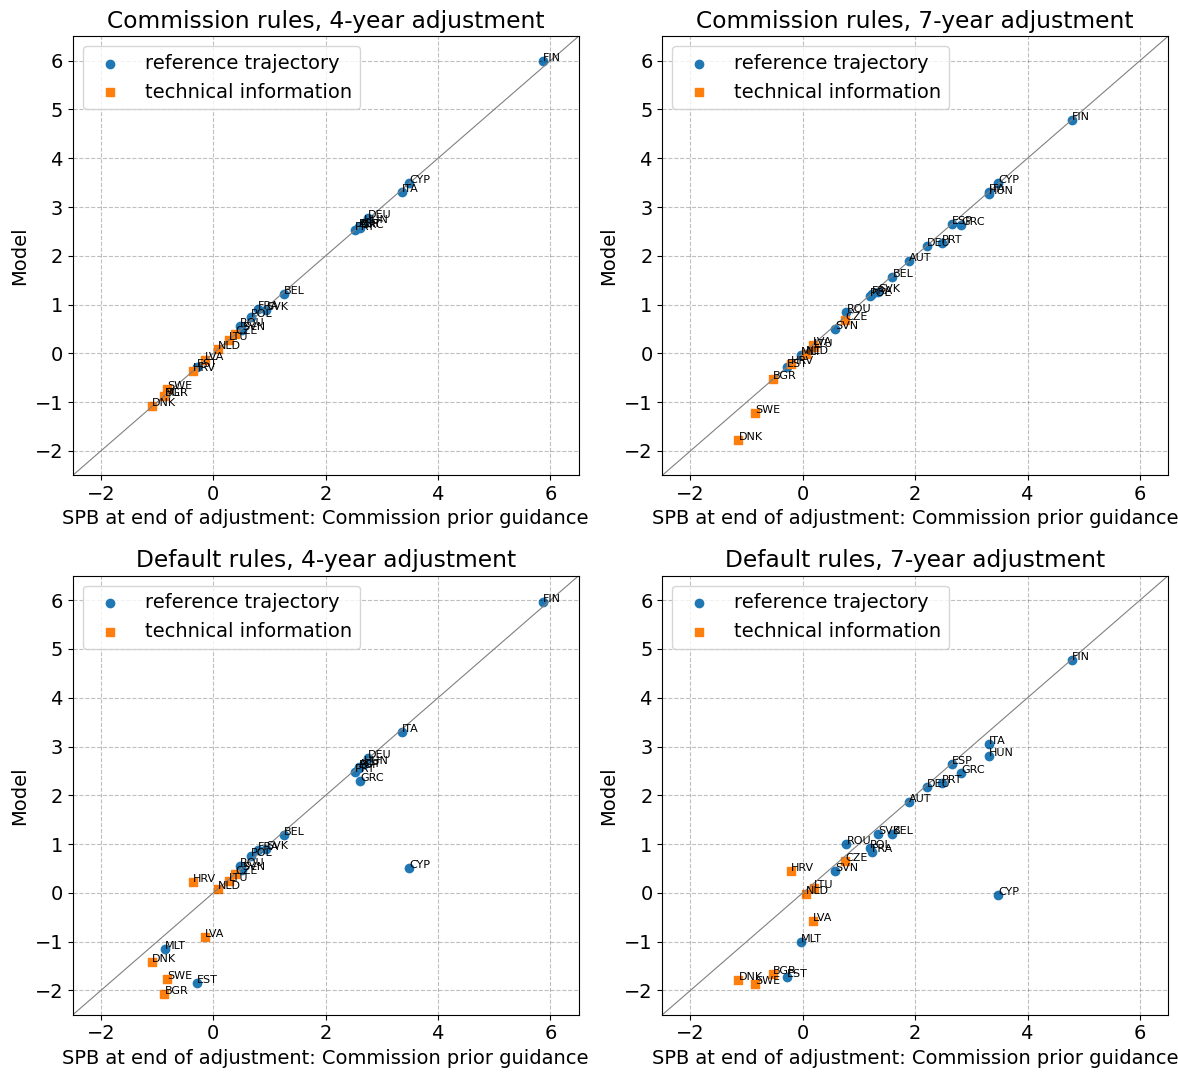

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for row, (label, df_rules) in enumerate([('Commission rules', summary), ('Default rules', summary_default)]):
    for col, n in enumerate([4, 7]):
        ax = axes[row, col]
        df = df_rules.loc[df_rules['adjustment_period'] == n].dropna(subset=['commission_spb_end'])
        for guidance, marker in [('reference trajectory', 'o'), ('technical information', 's')]:
            d = df.loc[df['guidance'] == guidance]
            ax.scatter(d['commission_spb_end'], d['model_spb_end'], marker=marker, label=guidance)
            for _, r in d.iterrows():
                ax.annotate(r['country'], (r['commission_spb_end'], r['model_spb_end']), fontsize=8)
        lim = [-2.5, 6.5]
        ax.plot(lim, lim, color='grey', lw=0.8)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_title(f'{label}, {n}-year adjustment')
        ax.set_xlabel('SPB at end of adjustment: Commission prior guidance'); ax.set_ylabel('Model'); ax.legend(loc='upper left')
plt.tight_layout()

In [10]:
# Absolute differences to the Commission guidance, SPB at end of adjustment (pp. of GDP)
stats = {label: df.assign(abs_diff=df['diff_spb_end'].abs()).groupby(['guidance', 'adjustment_period'])['abs_diff']
         .describe()[['count', '50%', 'max']] for label, df in [('Commission rules', summary), ('Default rules', summary_default)]}
pd.concat(stats, axis=1).round(2)

Commission rules            \
                                                   count  50%  max   
guidance              adjustment_period                              
not found             4                             0.00  NaN  NaN   
                      7                             0.00  NaN  NaN   
reference trajectory  4                            17.00 0.04 0.12   
                      7                            17.00 0.01 0.21   
technical information 4                             8.00 0.00 0.09   
                      7                             8.00 0.07 0.63   

                                        Default rules            
                                                count  50%  max  
guidance              adjustment_period                          
not found             4                          0.00  NaN  NaN  
                      7                          0.00  NaN  NaN  
reference trajectory  4                         17.00 0.07 2.98  
                      7                         17.00 0.27 3.52  
technical information 4                          8.00 0.46 1.20  
                      7                          8.00 0.65 1.13

- With the **Commission rules**, the model reproduces the Commission's SPB targets within a few hundredths of a percentage point for most countries (see section 7 for the remaining differences).
- With the **default rules**, targets are identical or close for most reference trajectories with a 4-year adjustment period. Larger deviations arise where the rules differ in substance; section 6 attributes them to individual rules.

### Notes on the Commission replication

**Reproduced Commission conventions** (all set through the input workbook, not hard-coded):
- *Forecast years*: the implicit interest rate follows the forecast up to the last forecast year (T+1 for spring, T+2 for autumn forecasts) and is projected thereafter. In forecast years, only the deviation from the forecast output gap decays after an SPB change.
- *Multiplier*: SPB changes lower growth by the multiplier (0.75; 0.6 in guidance issued from 2025) in the year of the change; the resulting output gap closes by 1/3 per year. Without SPB changes, growth follows the baseline.
- *Market rates and inflation*: linear convergence to T+10 (Bloomberg forward rates, inflation swaps) and T+30 anchors.
- *One-off measures* enter the primary balance but not the SPB; *stock-flow adjustments* include exchange rate effects.
- *Greece*: the Commission adds the difference between its Stata model and the Excel approximation to the implicit interest rate (up to 0.5 pp.), provided as `IMPLICIT_INTEREST_RATE_ADJ`.
- *Adjustments* are rounded up to the next 0.01 pp.; reference trajectories are non-negative, technical information allows at most -1 pp. per year.
- *Debt safeguard*: debt bands (above 90%, 60-90%) refer to the debt ratio at the start of each year; the average excludes years under EDP.

**Remaining differences** are small in most cases and plausible given that the model translates the legal rules consistently across countries:
- *Stochastic criterion*: the model uses its own historical shock data (Eurostat, OECD, ECB, up to 2026), the Commission uses its Stata simulations. This explains e.g. Finland (4-year).
- *Denmark*: the model floors the debt ratio at zero.
- *Deficit criterion*: the model requires a deficit of at most 3% of GDP, as in the regulation, in both rule sets. The evidence on the Commission's threshold is mixed: for reference trajectories, where the sheets report the DSA-based annual adjustment, a tolerance up to 3.05% reproduces it slightly better (the model with 3% is 0.01 to 0.03 pp. per year higher, e.g. France, Poland and Romania, 4-year), while for technical information 3% matches (e.g. Czechia, Lithuania, the Netherlands). With the Commission deficit resilience rule, such small differences can have large effects: for Sweden (7-year), the model's DSA-based step (-0.36 pp. per year) triggers the 0.25 pp. resilience step in a different number of years than a step of -0.37 pp. would, which shifts the SPB at the end of the adjustment period by about 0.6 pp.
- *Technical information with 7-year adjustment* (e.g. Sweden, Denmark) and the *updated Hungarian guidance*: the Commission's out-year projections are not published in the sheets, so these cannot be traced in detail.
- *Portugal and Greece (7-year)*: the model requires a somewhat smaller adjustment. The debt paths under the Commission SPB path match closely, and the binding criterion (debt declines in the adverse r-g scenario after the adjustment period) is the same, so the difference arises in the out-years beyond the horizon published in the sheets and cannot be traced in detail.
- *Ireland and Luxembourg* (2024) received technical information in a format without reported targets.

## Decomposition and discussion

### What drives the deviations

`data_pipeline.validate.compare_rules` starts from the Commission rules and switches groups of rules to the default version, with the Commission inputs of the 2024 guidance. Rules that interact are switched together: the **adjustment path rules** (front-loading of EDP and deficit resilience minimum steps, EDP, deficit resilience and debt safeguard rules) and the **DSA criteria** (deterministic and stochastic criteria, technical information and floors). The table shows the SPB at the end of the adjustment period and the differences to the Commission rules, for countries where the default rules differ by more than 0.1 pp.; effects need not add up.

In [11]:
# from data_pipeline.validate import compare_rules
# table, _ = compare_rules('dsa_inputs_commission_2024.xlsx',
#                          out_file=REPO_ROOT / 'output' / 'validation' / 'commission_2024_rule_comparison.xlsx')

rule_comparison = pd.read_excel(REPO_ROOT / 'output' / 'validation' / 'commission_2024_rule_comparison.xlsx',
                                sheet_name='spb_end', index_col=[0, 1])
drivers = rule_comparison.drop(columns='Commission rules').sub(rule_comparison['Commission rules'], axis=0)
drivers.columns = [f'{c}: difference' for c in drivers.columns]
table = pd.concat([rule_comparison[['Commission rules', 'Default rules']], drivers], axis=1)

# Countries and adjustment periods where the default rules differ from the Commission rules by more than 0.1 pp.
table.loc[table['Default rules: difference'].abs() > 0.1].round(2)

Commission rules  Default rules  \
country adjustment_period                                    
BEL     7                              1.57           1.21   
BGR     4                             -0.88          -2.07   
        7                             -0.52          -1.66   
HRV     4                             -0.36           0.22   
        7                             -0.21           0.45   
CYP     4                              3.48           0.50   
        7                              3.48          -0.04   
DNK     4                             -1.09          -1.41   
EST     4                             -0.29          -1.84   
        7                             -0.29          -1.72   
FRA     7                              1.22           0.84   
GRC     4                              2.58           2.30   
        7                              2.64           2.46   
HUN     7                              3.27           2.80   
ITA     7                              3.31           3.05   
LVA     4                             -0.13          -0.91   
        7                              0.18          -0.57   
MLT     4                             -0.87          -1.14   
        7                             -0.03          -1.02   
POL     7                              1.18           0.92   
ROU     7                              0.84           1.01   
SWE     4                             -0.74          -1.77   
        7                             -1.22          -1.87   

                           Adjustment path rules: difference  \
country adjustment_period                                      
BEL     7                                              -0.31   
BGR     4                                              -1.17   
        7                                              -1.08   
HRV     4                                              -0.12   
        7                                              -0.03   
CYP     4                                               0.00   
        7                                               0.00   
DNK     4                                               0.00   
EST     4                                               0.00   
        7                                               0.00   
FRA     7                                              -0.27   
GRC     4                                              -0.25   
        7                                              -0.14   
HUN     7                                              -0.36   
ITA     7                                              -0.23   
LVA     4                                              -1.11   
        7                                              -1.26   
MLT     4                                              -0.19   
        7                                              -0.91   
POL     7                                              -0.26   
ROU     7                                               0.00   
SWE     4                                              -1.01   
        7                                              -0.61   

                           DSA criteria: difference  Default rules: difference  
country adjustment_period                                                       
BEL     7                                      0.00                      -0.36  
BGR     4                                      0.00                      -1.19  
        7                                      0.00                      -1.14  
HRV     4                                      0.60                       0.58  
        7                                      0.70                       0.66  
CYP     4                                     -2.96                      -2.98  
        7                                     -3.50                      -3.52  
DNK     4                                     -0.32                      -0.33  
EST     4                                     -0.74              

The deviations have two sources:
- **Adjustment path rules.** The Commission sheets assume a constant annual adjustment and add the minimum steps of the EDP and the deficit resilience safeguard on top where they bind, which raises the SPB at the end of the adjustment period. The default rules front-load these minimum steps and reduce later steps, so that the SPB target is met with a front-loaded path. This lowers the targets of EDP countries with a 7-year adjustment period (Belgium, France, Hungary, Italy, Poland: about 0.2 to 0.4 pp.; Malta about 0.9 pp.), and of countries with low debt but a structural deficit above 1.5% (Bulgaria, Latvia, Sweden: about 0.6 to 1.3 pp.).
- **DSA criteria.** The Commission floors the annual adjustment at 0 pp. for reference trajectories and at -1 pp. for technical information; the default rules have no floor. This explains the largest differences: Cyprus (about 3 to 3.5 pp.), whose high SPB could decline while meeting the DSA criteria, Estonia and Denmark. For countries with debt below 60% and a deficit below 3%, the Commission provides technical information (deficit criterion and debt below 60% only), while the default rules apply all DSA criteria: the target of Croatia is higher (about 0.6 to 0.7 pp.), as the stochastic criterion binds.

Small remaining differences reflect the rounding of the annual adjustment in the Commission sheets.

### Which reading of the regulation?

Both implementations translate Regulation (EU) 2024/1263 into a computable rule; they differ where the regulation leaves room for interpretation.

- **Case for the Commission implementation.** Recital 21 states that, for the first national medium-term fiscal-structural plans, the plausibility of the debt ratio declining should be based on the methodology of the Commission's Debt Sustainability Monitor 2023. This can be taken to mean that the Commission's DSA, as operationalised in its prior guidance, should be used, including its constant adjustment path. The Commission reading is also more literal on the stochastic criterion: Article 10(1)(b) refers to the risk of the debt ratio *not decreasing*, while the default rules also accept debt staying below 60% (Article 6(a): "stays at prudent levels below 60 % of GDP").
- **Case for the default rules.** The Articles allow, and in places favour, the default reading:
  - Article 6(c) requires the adjustment effort to be "linear as a rule and at least proportional to the total effort over the entire adjustment period". This allows front-loading: the minimum steps of the EDP and the deficit resilience safeguard can be met by a front-loaded path, without raising the SPB at the end of the adjustment period.
  - Article 8(1) requires that fiscal adjustment "continues, where needed, until" the resilience margin of 1.5% of GDP is reached, which the default rules implement directly.
  - Article 10(1)(a) requires that the debt ratio "declines or stays at prudent levels, under the deterministic scenarios", which reads naturally per scenario.
  - The Articles set no floor on the annual adjustment.
  - In practice, the medium-term fiscal-structural plans submitted and endorsed in 2024 and 2025 showed front-loaded adjustment paths rather than constant ones.

Both readings are available in the model. We use the default rules as the default, as a consistent translation of the legal text that is closer to the adjustment paths of the actual plans, and report the Commission implementation for comparison. In both versions, the EDP status is taken from the input data (Article 7(2) refers to an EDP in place); `edp_status='infer'` lets the model predict it from a projected deficit above 3% of GDP.